In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import json, os
from scipy import stats
import pandas as pd
from tools import get_as_results, get_parallel_results, to_table, combine_algorithm_selection_score, compute_mcnemar, get_as_accuracy_results, compare_as_accuracy_results, compare_par_results
from sklearn.metrics import accuracy_score

In [2]:
total = {
    'wl-1': {'scores': {'svc': [], 'forest': [], 'nn': []}, 'accuracy': {'svc': [], 'forest': [], 'nn': []}, 'par': {'svc': [], 'forest': [], 'nn': []}},
    'wl-2': {'scores': {'svc': [], 'forest': [], 'nn': []}, 'accuracy': {'svc': [], 'forest': [], 'nn': []}, 'par': {'svc': [], 'forest': [], 'nn': []}},

    'wle-1': {'scores': {'svc': [], 'forest': [], 'nn': []}, 'accuracy': {'svc': [], 'forest': [], 'nn': []}, 'par': {'svc': [], 'forest': [], 'nn': []}},
    'wle-2': {'scores': {'svc': [], 'forest': [], 'nn': []}, 'accuracy': {'svc': [], 'forest': [], 'nn': []}, 'par': {'svc': [], 'forest': [], 'nn': []}},

    'wln-1': {'scores': {'svc': [], 'forest': [], 'nn': []}, 'accuracy': {'svc': [], 'forest': [], 'nn': []}, 'par': {'svc': [], 'forest': [], 'nn': []}},
    'wln-2': {'scores': {'svc': [], 'forest': [], 'nn': []}, 'accuracy': {'svc': [], 'forest': [], 'nn': []}, 'par': {'svc': [], 'forest': [], 'nn': []}},

    'wlne-1': {'scores': {'svc': [], 'forest': [], 'nn': []}, 'accuracy': {'svc': [], 'forest': [], 'nn': []}, 'par': {'svc': [], 'forest': [], 'nn': []}},
    'wlne-2': {'scores': {'svc': [], 'forest': [], 'nn': []}, 'accuracy': {'svc': [], 'forest': [], 'nn': []}, 'par': {'svc': [], 'forest': [], 'nn': []}},

    'wlc-1': {'scores': {'svc': [], 'forest': [], 'nn': []}, 'accuracy': {'svc': [], 'forest': [], 'nn': []}, 'par': {'svc': [], 'forest': [], 'nn': []}},
    'wlc-2': {'scores': {'svc': [], 'forest': [], 'nn': []}, 'accuracy': {'svc': [], 'forest': [], 'nn': []}, 'par': {'svc': [], 'forest': [], 'nn': []}},

    'wlce-1': {'scores': {'svc': [], 'forest': [], 'nn': []}, 'accuracy': {'svc': [], 'forest': [], 'nn': []}, 'par': {'svc': [], 'forest': [], 'nn': []}},
    'wlce-2': {'scores': {'svc': [], 'forest': [], 'nn': []}, 'accuracy': {'svc': [], 'forest': [], 'nn': []}, 'par': {'svc': [], 'forest': [], 'nn': []}},

    'fzn2feat': {'scores': {'svc': [], 'forest': [], 'nn': []}, 'accuracy': {'svc': [], 'forest': [], 'nn': []}, 'par': {'svc': [], 'forest': [], 'nn': []}},
}

score_folder = '../data/as-scores-results/'
for model in ['svc', 'forest', 'nn']:
    folder = score_folder + model + '-scores/'
    for file in os.listdir(folder):
        assert 'json' in file
        mn = model if model != 'forest' else 'rnd-forest'
        feature_set = file.replace('as_', '').split(f'-{mn}-')[0]
        total[feature_set]['scores'][model].append(file)
from pprint import pp
for feature_set in total.keys():
    for model in ['svc', 'forest', 'nn']:
        assert len(total[feature_set]['scores'][model]) == len(set(total[feature_set]['scores'][model]))
        total[feature_set]['scores'][model] = len(total[feature_set]['scores'][model])

accuracy_folder = '../data/as-accuracy-results/'
for model in ['svc', 'forest', 'nn']:
    folder = accuracy_folder + model + '-scores/'
    for file in os.listdir(folder):
        assert 'json' in file
        mn = model if model != 'forest' else 'rnd-forest'
        feature_set = file.replace('as-accuracy_', '').split(f'-{mn}-')[0]
        total[feature_set]['accuracy'][model].append(file)
from pprint import pp
for feature_set in total.keys():
    for model in ['svc', 'forest', 'nn']:
        assert len(total[feature_set]['accuracy'][model]) == len(set(total[feature_set]['accuracy'][model]))
        total[feature_set]['accuracy'][model] = len(total[feature_set]['accuracy'][model])

parallel_folder = '../data/parallelise-results/'
for model in ['svc', 'forest', 'nn']:
    folder = parallel_folder + model + '-parallelise/'
    for file in os.listdir(folder):
        assert 'json' in file
        mn = model if model != 'forest' else 'rnd-forest'
        feature_set = file.replace('par_', '').split(f'-{mn}-')[0]
        total[feature_set]['par'][model].append(file)
from pprint import pp
for feature_set in total.keys():
    for model in ['svc', 'forest', 'nn']:
        assert len(total[feature_set]['par'][model]) == len(set(total[feature_set]['par'][model]))
        total[feature_set]['par'][model] = len(total[feature_set]['par'][model])

total_missing = 0
for feature_set in total.keys():
    print("===========================================")
    total_missing += (50 - total[feature_set]["scores"]["svc"]) + (50 - total[feature_set]["scores"]["forest"]) + (50 - total[feature_set]["scores"]["nn"]) \
                   + (50 - total[feature_set]["accuracy"]["svc"]) + (50 - total[feature_set]["accuracy"]["forest"]) + (50 - total[feature_set]["accuracy"]["nn"]) \
                   + (50 - total[feature_set]["par"]["svc"]) + (50 - total[feature_set]["par"]["forest"]) + (50 - total[feature_set]["par"]["nn"])
    print(f'''{feature_set}: 
scores: ({50 - total[feature_set]["scores"]["svc"]}, {50 - total[feature_set]["scores"]["forest"]}, {50 - total[feature_set]["scores"]["nn"]})
accuracy: ({50 - total[feature_set]["accuracy"]["svc"]}, {50 - total[feature_set]["accuracy"]["forest"]}, {50 - total[feature_set]["accuracy"]["nn"]})
parallel: ({50 - total[feature_set]["par"]["svc"]}, {50 - total[feature_set]["par"]["forest"]}, {50 - total[feature_set]["par"]["nn"]})''')

print("total missing experiments:", total_missing)

wl-1: 
scores: (0, 0, 50)
accuracy: (0, 0, 50)
parallel: (0, 26, 50)
wl-2: 
scores: (0, 50, 50)
accuracy: (50, 50, 50)
parallel: (25, 50, 50)
wle-1: 
scores: (0, 0, 31)
accuracy: (0, 0, 50)
parallel: (0, 0, 50)
wle-2: 
scores: (0, 0, 45)
accuracy: (50, 50, 50)
parallel: (25, 50, 50)
wln-1: 
scores: (0, 0, 47)
accuracy: (0, 0, 50)
parallel: (0, 0, 48)
wln-2: 
scores: (0, 0, 49)
accuracy: (0, 0, 50)
parallel: (0, 0, 50)
wlne-1: 
scores: (0, 0, 47)
accuracy: (0, 0, 50)
parallel: (0, 0, 48)
wlne-2: 
scores: (0, 0, 50)
accuracy: (0, 0, 50)
parallel: (0, 0, 50)
wlc-1: 
scores: (0, 0, 0)
accuracy: (0, 0, 0)
parallel: (0, 0, 0)
wlc-2: 
scores: (0, 0, 0)
accuracy: (0, 0, 0)
parallel: (0, 0, 0)
wlce-1: 
scores: (0, 0, 0)
accuracy: (0, 0, 0)
parallel: (0, 0, 16)
wlce-2: 
scores: (0, 0, 0)
accuracy: (0, 0, 36)
parallel: (0, 0, 50)
fzn2feat: 
scores: (0, 0, 0)
accuracy: (0, 0, 0)
parallel: (0, 0, 0)
total missing experiments: 1693


# Borda-count Scores

In [3]:
folder = '../data/as-scores-results/svc-scores'
dataset = '../data/algorithm_selection_dataset_score.csv'
print(folder, ':')
res_svc = get_as_results(folder)
# res_svc['combined-fzn2feat'] = {}
# res_svc['combined-wlc'] = {}
# for seed in ["7", '12', "42", "72", "123", "156", "197", "205", "224", "242"]:
#     for fold in range(5):
#         s1 = f'../data/as-scores-results/svc-scores/as_wlc-1-svc-{fold}-{seed}.json'
#         s2 = f'../data/as-scores-results/svc-scores/as_wlc-2-svc-{fold}-{seed}.json'
#         s3 = f'../data/as-scores-results/forest-scores/as_fzn2feat-rnd-forest-{fold}-{seed}.json'
#         res_svc['combined-fzn2feat'][f'{fold}-{seed}'] = combine_algorithm_selection_score(s1, s2, dataset, s3)
#         res_svc['combined-wlc'][f'{fold}-{seed}'] = combine_algorithm_selection_score(s1, s2, dataset)
fzn2feat = list(res_svc['fzn2feat'].values())
t_stat, p_value = stats.wilcoxon(list(res_svc['wlc-1'].values()), fzn2feat)
print("wlc-1:", p_value)
t_stat, p_value = stats.wilcoxon(list(res_svc['wlc-2'].values()), fzn2feat)
print("wlc-2:", p_value)
display(to_table(res_svc))

../data/as-scores-results/svc-scores :
wlc-1: 0.002996250182501825
wlc-2: 0.01958777690517799


,Mean,Median,Std,Max,Min,Worse_sbs
fzn2feat,0.403998,0.393410,0.144663,0.695461,0.060593,0
wl-1,0.197307,0.221347,0.151943,0.493598,-0.294077,7
wle-1,0.128665,0.152632,0.246157,0.534528,-0.919572,11
wle-2,0.104841,0.139820,0.254606,0.470660,-0.696799,12
wln-1,0.210201,0.244648,0.188278,0.499440,-0.336539,7
wln-2,0.282667,0.276099,0.149708,0.586188,-0.102522,2
wlne-1,0.225815,0.258215,0.191720,0.490823,-0.413963,5
wlne-2,0.275569,0.274540,0.167006,0.612715,-0.129162,3
wlc-1,0.484961,0.506030,0.160183,0.743272,0.070355,0
wlc-2,0.472466,0.503657,0.196363,0.743609,-0.363986,1


../data/as-scores-results/svc-scores :


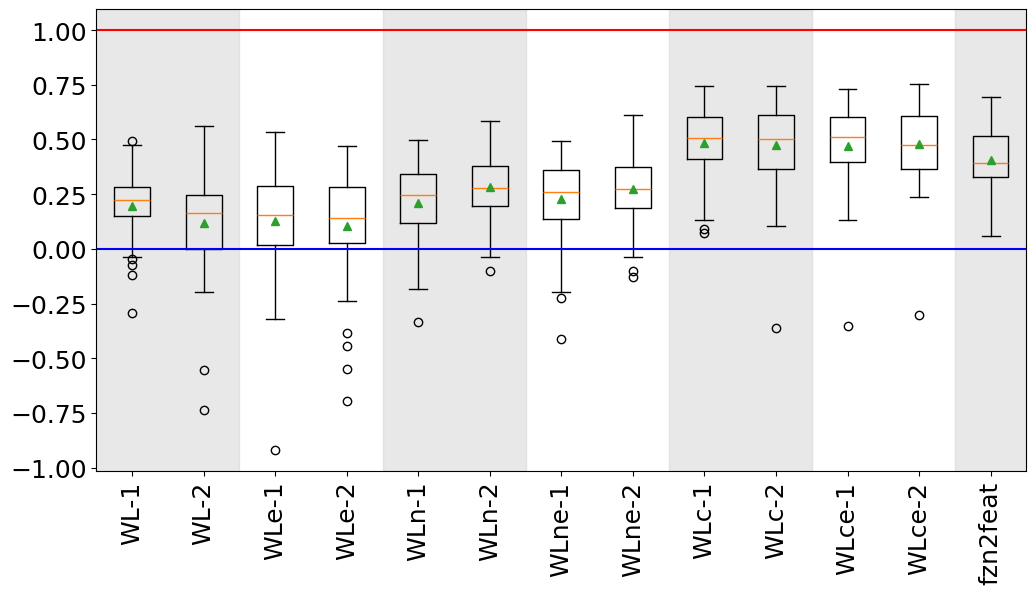

In [26]:
folder = '../data/as-scores-results/svc-scores'
matplotlib.rcParams['font.family'] = 'sans-serif'

matplotlib.rcParams.update({'font.size': 18})
print(folder, ':')
res_svc = get_as_results(folder)
plot_res = {
    features: list(v.values()) for features, v in res_svc.items()
}
fzn2feat = plot_res['fzn2feat']
del plot_res['fzn2feat']
plot_res['fzn2feat'] = fzn2feat
fig, ax = plt.subplots(figsize=(12,6))
violin_parts = ax.boxplot(plot_res.values(), showmeans=True)

ax.axhline(y=1, c='red')
ax.axhline(y=0, c='blue')

ax.set_xlim(0.5, len(plot_res.keys())+.5)
ax.axvspan(0, 2.5, color='lightgrey', alpha=0.5)
ax.axvspan(4.5, 6.5, color='lightgrey', alpha=0.5)
ax.axvspan(8.5, 10.5, color='lightgrey', alpha=0.5)
ax.axvspan(12.5, 13.5, color='lightgrey', alpha=0.5)

plt.xticks([i for i in range(1, len(plot_res.keys())+1)], [k.replace("wl", "WL") for k in plot_res.keys()], rotation='vertical')
plt.savefig('../paper/figures/wl_score_svc.pdf', format='pdf', bbox_inches='tight',)
plt.show()

In [12]:
print('Statistical significance matrix (no fzn2feat):')
folder = '../data/as-scores-results/svc-scores'
WORSE = '\\textcolor{red}{$\\times$}'
BETTER = '\\textcolor{ForestGreen}{\\checkmark}'
EQUAL = '\\textbf{--}'

res_svc = get_as_results(folder)
features = [f for f in res_svc.keys() if f != 'fzn2feat']
features.append('fzn2feat')
rows = {feat:{ft:'' for ft in features} for feat in features}
for ft1 in features:
    for ft2 in features:
        if ft1 == ft2:
            rows[ft1][ft2] = EQUAL
            continue
        ft1_results = list(res_svc[ft1].values())
        ft2_results = list(res_svc[ft2].values())
        try:
            _, p_value = stats.wilcoxon(ft1_results, ft2_results)
        except Exception as e:
            print(ft1, ft2)
            raise e
        if p_value < .05:
            if np.median(ft1_results) > np.median(ft2_results):
                rows[ft2][ft1] = BETTER
            else:
                rows[ft2][ft1] = WORSE
        else:
            rows[ft1][ft2] = EQUAL
print(pd.DataFrame(rows).to_latex())

Statistical significance matrix (no fzn2feat):
\begin{tabular}{llllllllllllll}
\toprule
 & wl-1 & wl-2 & wle-1 & wle-2 & wln-1 & wln-2 & wlne-1 & wlne-2 & wlc-1 & wlc-2 & wlce-1 & wlce-2 & fzn2feat \\
\midrule
wl-1 & \textbf{--} & \textcolor{ForestGreen}{\checkmark} & \textbf{--} & \textbf{--} & \textbf{--} & \textcolor{red}{$\times$} & \textbf{--} & \textcolor{red}{$\times$} & \textcolor{red}{$\times$} & \textcolor{red}{$\times$} & \textcolor{red}{$\times$} & \textcolor{red}{$\times$} & \textcolor{red}{$\times$} \\
wl-2 & \textcolor{red}{$\times$} & \textbf{--} & \textbf{--} & \textbf{--} & \textcolor{red}{$\times$} & \textcolor{red}{$\times$} & \textcolor{red}{$\times$} & \textcolor{red}{$\times$} & \textcolor{red}{$\times$} & \textcolor{red}{$\times$} & \textcolor{red}{$\times$} & \textcolor{red}{$\times$} & \textcolor{red}{$\times$} \\
wle-1 & \textbf{--} & \textbf{--} & \textbf{--} & \textbf{--} & \textbf{--} & \textcolor{red}{$\times$} & \textcolor{red}{$\times$} & \textcolor{red

In [52]:
folder = '../data/as-scores-results/forest-scores'
print(folder, ':')
res_forest = get_as_results(folder)
fzn2feat = list(res_forest['fzn2feat'].values())
t_stat, p_value = stats.wilcoxon(list(res_forest['wlc-1'].values()), fzn2feat)
print('wlc-1:', p_value)
t_stat, p_value = stats.wilcoxon(list(res_forest['wlc-2'].values()), fzn2feat)
print('wlc-2:', p_value)
display(to_table(res_forest))

../data/as-scores-results/forest-scores :
wlc-1: 0.5526669770606443
wlc-2: 0.6736344940466168


,Mean,Median,Std,Max,Min,Worse_sbs
fzn2feat,0.453126,0.469145,0.169899,0.793287,-0.085975,1
wl-1,0.247356,0.262464,0.141575,0.505527,-0.191213,3
wle-1,0.349537,0.357495,0.164811,0.645770,-0.173245,1
wle-2,0.416928,0.425804,0.118646,0.635813,0.167517,0
wln-1,0.430599,0.433760,0.140518,0.747006,0.042360,0
wln-2,0.448705,0.454461,0.133005,0.668731,0.165787,0
wlne-1,0.439817,0.446640,0.110832,0.648780,0.184772,0
wlne-2,0.432966,0.412279,0.125370,0.668731,0.116504,0
wlc-1,0.442881,0.443803,0.141967,0.790252,0.172934,0
wlc-2,0.449713,0.443803,0.137703,0.715554,0.106153,0


../data/as-scores-results/forest-scores :


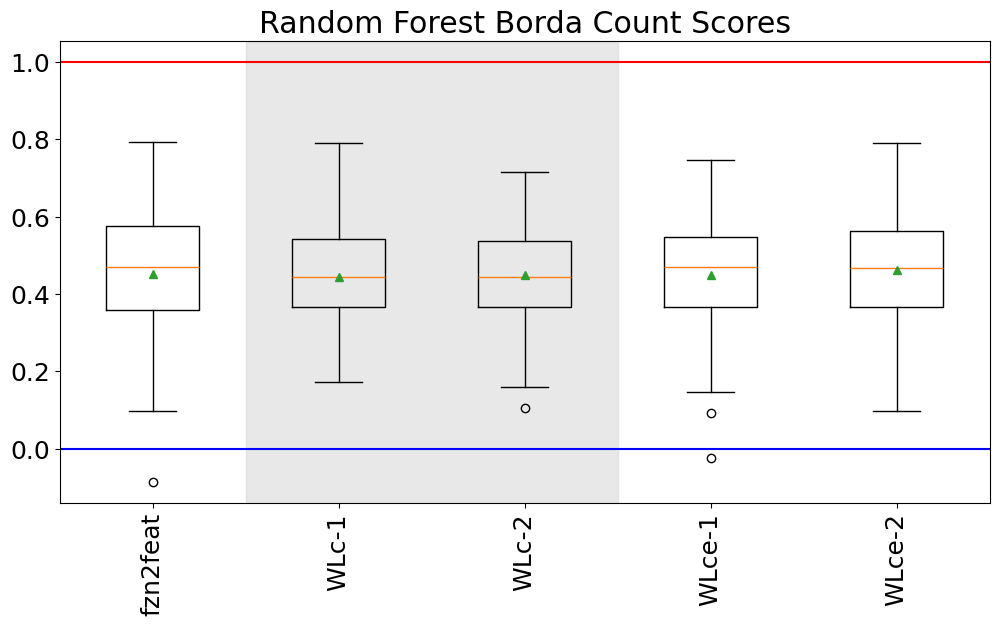

In [20]:
folder = '../data/as-scores-results/forest-scores'
matplotlib.rcParams['font.family'] = 'sans-serif'

matplotlib.rcParams.update({'font.size': 18})
print(folder, ':')
res_svc = get_as_results(folder)
plot_res = {
    features: list(v.values()) for features, v in res_svc.items() if 'wlc' in features or 'fzn2feat' in features
}
fig, ax = plt.subplots(figsize=(12,6))
violin_parts = ax.boxplot(plot_res.values(), showmeans=True)

ax.axhline(y=1, c='red')
ax.axhline(y=0, c='blue')

ax.set_xlim(0.5, len(plot_res.keys())+.5)
ax.axvspan(1.5, 3.5, color='lightgrey', alpha=0.5)
ax.set_title("Random Forest Borda Count Scores")


plt.xticks([i for i in range(1, len(plot_res.keys())+1)], [k.replace("wl", "WL") for k in plot_res.keys()], rotation='vertical')
plt.savefig('../paper/figures/wl-fzn2feat_score_forest.pdf', format='pdf', bbox_inches='tight',)
plt.show()

In [51]:
print('Statistical significance matrix (fzn2feat -vs- wlc):')
folder = '../data/as-scores-results/forest-scores'
WORSE = 'W'
BETTER = 'B'
EQUAL = 'E'

res_svc = get_as_results(folder)
features = [f for f in res_svc.keys() if f == 'fzn2feat' or 'wlc' in f]
rows = {feat:{ft:'' for ft in features} for feat in features}
for ft1 in features:
    for ft2 in features:
        # if ft1 == 'wlce-2' or ft2 == 'wlce-2':
        #     continue 
        if ft1 == ft2:
            rows[ft1][ft2] = EQUAL
            continue
        ft1_results = list(res_svc[ft1].values())
        ft2_results = list(res_svc[ft2].values())
        try:
            _, p_value = stats.wilcoxon(ft1_results, ft2_results)
        except Exception as e:
            print(ft1, ft2)
            raise e
        if p_value < .05:
            if np.median(ft1_results) > np.median(ft2_results):
                rows[ft2][ft1] = BETTER + f'({p_value:.2f})'
            else:
                rows[ft2][ft1] = WORSE + f'({p_value:.2f})'
        else:
            rows[ft2][ft1] = EQUAL + f'({p_value:.2f})'
display(pd.DataFrame(rows))

Statistical significance matrix (fzn2feat -vs- wlc):


,fzn2feat,wlc-1,wlc-2,wlce-1,wlce-2
fzn2feat,E,E(0.55),E(0.67),E(0.78),E(0.52)
wlc-1,E(0.55),E,E(0.77),E(0.55),E(0.55)
wlc-2,E(0.67),E(0.77),E,E(0.93),E(0.71)
wlce-1,E(0.78),E(0.55),E(0.93),E,E(0.80)
wlce-2,E(0.52),E(0.55),E(0.71),E(0.80),E


In [53]:
folder = '../data/as-scores-results/nn-scores'
print(folder, ':')
res = get_as_results(folder)
fzn2feat = list(res['fzn2feat'].values())
t_stat, p_value = stats.wilcoxon(list(res['wlc-1'].values()), fzn2feat)
print("wlc-1:", p_value)
t_stat, p_value = stats.wilcoxon(list(res['wlc-2'].values()), fzn2feat)
print("wlc-2:", p_value)
# t_stat, p_value = stats.wilcoxon(list(res['wlce-1'].values()), fzn2feat)
# print("wlce-1:", p_value)
display(to_table(res))

../data/as-scores-results/nn-scores :
wlc-1: 0.054216182330456775
wlc-2: 0.03996834652842374


,Mean,Median,Std,Max,Min,Worse_sbs
fzn2feat,0.320309,0.349813,0.213622,0.743848,-0.252822,3
wlc-1,0.399279,0.412857,0.133137,0.720193,0.078721,0
wlc-2,0.392549,0.409654,0.142383,0.637640,0.033634,0
wlce-1,0.411098,0.400557,0.141634,0.655262,0.002848,0
wle-1,-0.167456,-0.111961,0.328163,0.300262,-0.779828,13
wln-1,0.368091,0.441234,0.167461,0.486539,0.176500,0
wlne-1,0.317350,0.370441,0.171619,0.456150,0.125459,0
wln-2,0.042531,0.042531,NaN,0.042531,0.042531,0


../data/as-scores-results/nn-scores :


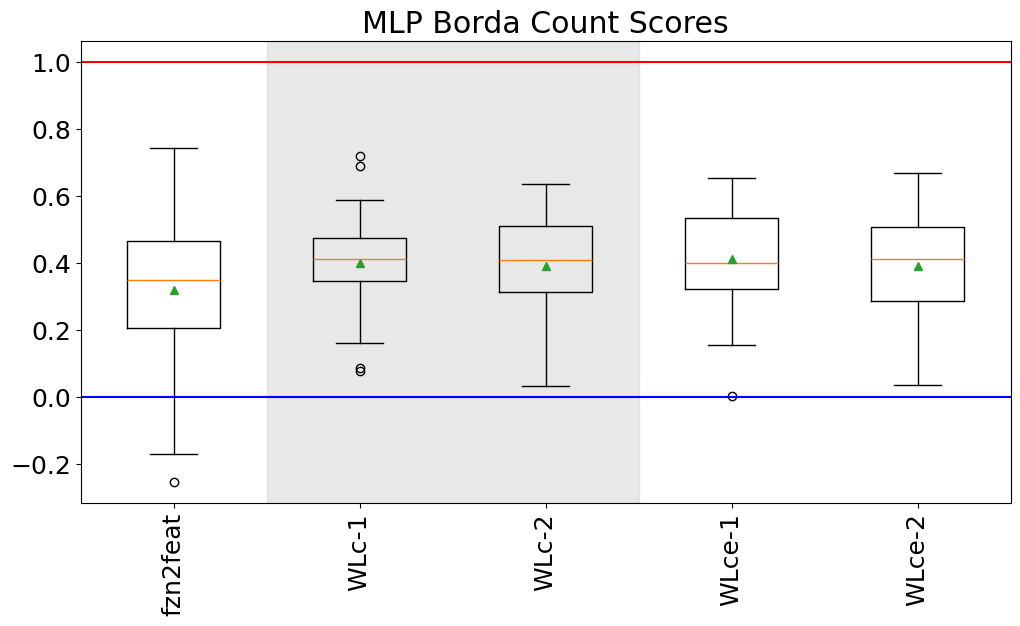

In [21]:
folder = '../data/as-scores-results/nn-scores'
matplotlib.rcParams['font.family'] = 'sans-serif'

matplotlib.rcParams.update({'font.size': 18})
print(folder, ':')
res_svc = get_as_results(folder)
plot_res = {
    features: list(v.values()) for features, v in res_svc.items() if 'wlc' in features or 'fzn2feat' in features
}
fig, ax = plt.subplots(figsize=(12,6))
violin_parts = ax.boxplot(plot_res.values(), showmeans=True)

ax.axhline(y=1, c='red')
ax.axhline(y=0, c='blue')

ax.set_xlim(0.5, len(plot_res.keys())+.5)
ax.axvspan(1.5, 3.5, color='lightgrey', alpha=0.5)
ax.set_title("MLP Borda Count Scores")

plt.xticks([i for i in range(1, len(plot_res.keys())+1)], [k.replace("wl", "WL") for k in plot_res.keys()], rotation='vertical')
plt.savefig('../paper/figures/wl-fzn2feat_score_nn.pdf', format='pdf', bbox_inches='tight',)
plt.show()

In [47]:
print('Statistical significance matrix (fzn2feat -vs- wlc):')
folder = '../data/as-scores-results/nn-scores'
WORSE = 'W'
BETTER = 'B'
EQUAL = 'E'

res_svc = get_as_results(folder)
features = [f for f in res_svc.keys() if f == 'fzn2feat' or 'wlc' in f]
rows = {feat:{ft:'' for ft in features} for feat in features}
for ft1 in features:
    for ft2 in features:
        if 'wlce' in ft1 or 'wlce' in ft2:
            continue 
        if ft1 == ft2:
            rows[ft1][ft2] = EQUAL
            continue
        ft1_results = list(res_svc[ft1].values())
        ft2_results = list(res_svc[ft2].values())
        try:
            _, p_value = stats.wilcoxon(ft1_results, ft2_results)
        except Exception as e:
            print(ft1, ft2)
            raise e
        if p_value < .05:
            if np.median(ft1_results) > np.median(ft2_results):
                rows[ft2][ft1] = BETTER + f'({p_value:.3f})'
            else:
                rows[ft2][ft1] = WORSE + f'({p_value:.3f})'
        else:
            rows[ft2][ft1] = EQUAL + f'({p_value:.3f})'
display(pd.DataFrame(rows))

Statistical significance matrix (fzn2feat -vs- wlc):


,fzn2feat,wlc-1,wlc-2,wlce-1
fzn2feat,E,E(0.054),W(0.040),
wlc-1,E(0.054),E,E(0.572),
wlc-2,B(0.040),E(0.572),E,
wlce-1,,,,


In [54]:
res_forest = get_as_results('../data/as-scores-results/forest-scores')
res_svc = get_as_results('../data/as-scores-results/svc-scores')
fzn2feat = list(res_forest['fzn2feat'].values())
_, p_value = stats.wilcoxon(list(res_svc['wlc-1'].values()), fzn2feat)
print('wlc-1', p_value)
_, p_value = stats.wilcoxon(list(res_svc['wlc-2'].values()), fzn2feat)
print('wlc-2', p_value)
_, p_value = stats.wilcoxon(list(res_svc['wlce-1'].values()), fzn2feat)
print('wlce-1', p_value)
_, p_value = stats.wilcoxon(list(res_svc['wlce-2'].values()), fzn2feat)
print('wlce-2', p_value)

wlc-1 0.3673427625704484
wlc-2 0.3422827758111566
wlce-1 0.3374027667706141
wlce-2 0.46647302992520423


# Algorithm Selection Accuracy Scores

In [31]:
compare_as_accuracy_results(('wlc-1', 'svc'),('fzn2feat', 'forest'), '../data/as-accuracy-results')

(0.6948096885813149, 0.6667820069204152, 0.0006394217955246711)

In [55]:
folder = '../data/as-accuracy-results/svc-scores'
print(folder, ':')
res = get_as_accuracy_results(folder)
fzn2feat = list(res['fzn2feat'].values())
t_stat, p_value = stats.wilcoxon(list(res['wlc-1'].values()), fzn2feat)
print('wlc-1:', p_value)
t_stat, p_value = stats.wilcoxon(list(res['wlc-2'].values()), fzn2feat)
print('wlc-2:', p_value)
t_stat, p_value = stats.wilcoxon(list(res['wlc-2'].values()), list(res['wlc-1'].values()))
print('wlc-2:', p_value)
to_table(res, False)

../data/as-accuracy-results/svc-scores :
wlc-1: 1.6027711723756744e-05
wlc-2: 6.730663031992932e-05
wlc-2: 0.5113580487685174


,Mean,Median,Std,Max,Min
fzn2feat,0.628796,0.634755,0.058112,0.741379,0.517241
wl-1,0.569552,0.568966,0.059232,0.672414,0.421053
wle-1,0.586219,0.603448,0.080933,0.719298,0.362069
wln-1,0.588959,0.591349,0.052051,0.724138,0.465517
wln-2,0.606606,0.603448,0.049738,0.706897,0.482759
wlne-1,0.589310,0.599970,0.056227,0.724138,0.465517
wlne-2,0.605227,0.603448,0.050806,0.706897,0.482759
wlc-1,0.694737,0.681034,0.069942,0.879310,0.543860
wlc-2,0.686866,0.689655,0.066473,0.810345,0.551724
wlce-1,0.693019,0.689655,0.067105,0.810345,0.526316


../data/as-accuracy-results/svc-scores :


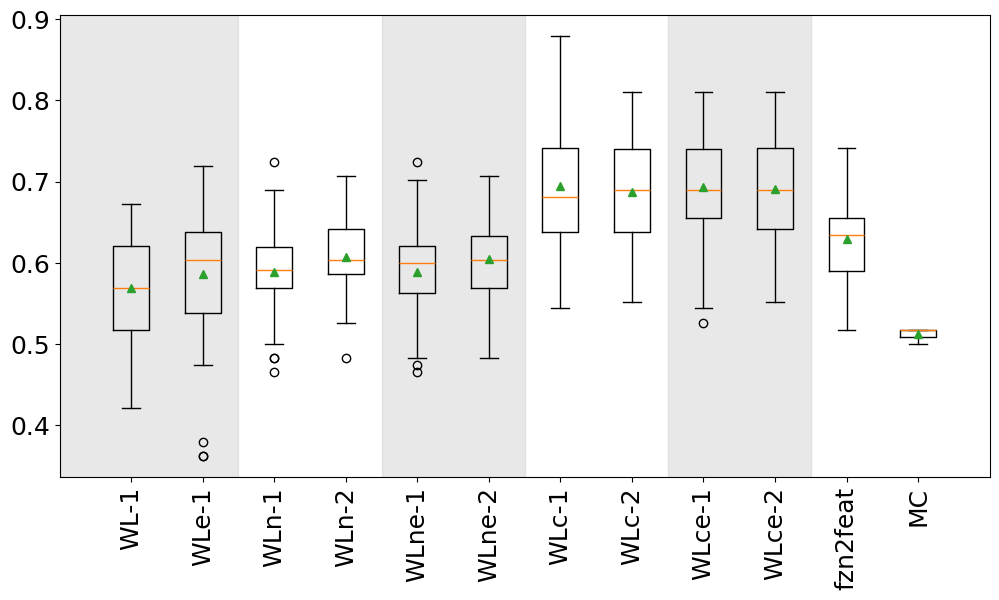

In [30]:
folder = '../data/as-accuracy-results/svc-scores'
matplotlib.rcParams['font.family'] = 'sans-serif'

matplotlib.rcParams.update({'font.size': 18})
print(folder, ':')
res_svc = get_as_accuracy_results(folder)
plot_res = {
    features: list(v.values()) for features, v in res_svc.items()
}
fzn2feat = plot_res['fzn2feat']
del plot_res['fzn2feat']
plot_res['fzn2feat'] = fzn2feat

majority_classifier = plot_res['majority_classifier']
del plot_res['majority_classifier']
plot_res['majority_classifier'] = majority_classifier
fig, ax = plt.subplots(figsize=(12,6))
violin_parts = ax.boxplot(plot_res.values(), showmeans=True)

ax.set_xlim(0, len(plot_res.keys())+1)
ax.axvspan(0, 2.5, color='lightgrey', alpha=0.5)
ax.axvspan(4.5, 6.5, color='lightgrey', alpha=0.5)
ax.axvspan(8.5, 10.5, color='lightgrey', alpha=0.5)

plt.xticks([i for i in range(1, len(plot_res.keys())+1)], [
    k.replace("wl", "WL") if k != 'majority_classifier' else 'MC' for k in plot_res.keys()], 
    rotation='vertical')
plt.savefig('../paper/figures/wl_accuracy_svc.pdf', format='pdf', bbox_inches='tight',)
plt.show()

In [12]:
folder = '../data/as-accuracy-results/forest-scores'
print(folder, ':')
res = get_as_accuracy_results(folder)
fzn2feat = list(res['fzn2feat'].values())
t_stat, p_value = stats.wilcoxon(list(res['wlc-1'].values()), fzn2feat)
print('wlc-1:', p_value)
t_stat, p_value = stats.wilcoxon(list(res['wlc-2'].values()), fzn2feat)
print('wlc-2:', p_value)
to_table(res, False)

../data/as-accuracy-results/forest-scores :
wlc-1: 0.7950904404103775
wlc-2: 0.6392932003541856


,Mean,Median,Std,Max,Min
fzn2feat,0.666836,0.672414,0.053620,0.758621,0.517241
wlc-1,0.666437,0.652148,0.055553,0.775862,0.568966
wlc-2,0.665741,0.655172,0.060089,0.827586,0.534483


In [34]:
print('wlc-1', compare_as_accuracy_results(('wlc-1', 'forest'),('fzn2feat', 'forest'), '../data/as-accuracy-results'))
print('wlc-2', compare_as_accuracy_results(('wlc-2', 'forest'),('fzn2feat', 'forest'), '../data/as-accuracy-results'))

wlc-1 (0.6664359861591695, 0.6667820069204152, 1.0)
wlc-2 (0.6657439446366782, 0.6667820069204152, 0.9186017169687883)


../data/as-accuracy-results/forest-scores :


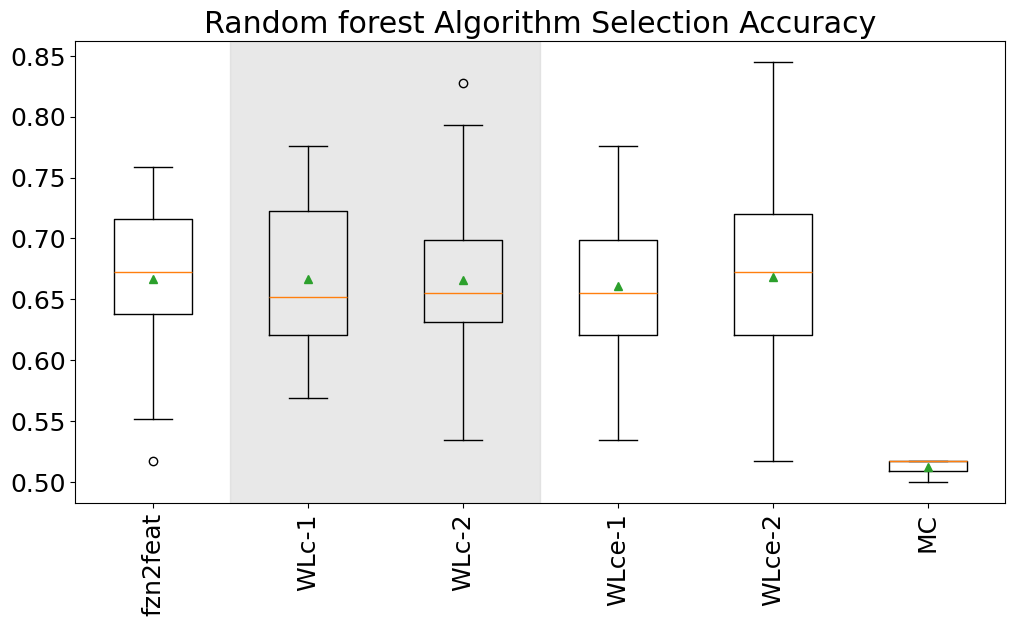

In [29]:
folder = '../data/as-accuracy-results/forest-scores'
matplotlib.rcParams['font.family'] = 'sans-serif'

matplotlib.rcParams.update({'font.size': 18})
print(folder, ':')
res_forest = get_as_accuracy_results(folder)
plot_res = {
    features: list(v.values()) for features, v in res_forest.items() if 'wlc' in features or 'fzn2feat' == features or 'majority_classifier' == features
}
fig, ax = plt.subplots(figsize=(12,6))
violin_parts = ax.boxplot(plot_res.values(), showmeans=True)

ax.set_xlim(.5, len(plot_res.keys())+.5)
ax.axvspan(1.5, 3.5, color='lightgrey', alpha=0.5)
ax.set_title("Random forest Algorithm Selection Accuracy")

plt.xticks([i for i in range(1, len(plot_res.keys())+1)], [
    k.replace("wl", "WL") if k != 'majority_classifier' else 'MC' for k in plot_res.keys()], 
    rotation='vertical')
plt.savefig('../paper/figures/wl-fzn2feat_accuracy_forest.pdf', format='pdf', bbox_inches='tight',)
plt.show()

In [25]:
folder = '../data/as-accuracy-results/nn-scores'
print(folder, ':')
res = get_as_accuracy_results(folder)
fzn2feat = list(res['fzn2feat'].values())
t_stat, p_value = stats.wilcoxon(list(res['wlc-1'].values()), fzn2feat)
print('wlc-1:', p_value)
t_stat, p_value = stats.wilcoxon(list(res['wlc-2'].values()), fzn2feat)
print('wlc-2:', p_value)
to_table(res, False)

../data/as-accuracy-results/nn-scores :
wlc-1: 0.8035336609877415
wlc-2: 0.7961309923635564


,Mean,Median,Std,Max,Min
fzn2feat,0.624598,0.620690,0.058175,0.775862,0.465517
wlc-1,0.628772,0.620690,0.058302,0.758621,0.500000
wlc-2,0.621440,0.626134,0.055993,0.741379,0.500000
wlce-1,0.613158,0.620690,0.060276,0.775862,0.500000
majority_classifier,0.512099,0.517241,0.006952,0.517241,0.500000
wlce-2,0.630866,0.629310,0.063656,0.724138,0.482759


In [36]:
print('wlc-1', compare_as_accuracy_results(('wlc-1', 'nn'),('fzn2feat', 'nn'), '../data/as-accuracy-results'))
print('wlc-2', compare_as_accuracy_results(('wlc-2', 'nn'),('fzn2feat', 'nn'), '../data/as-accuracy-results'))

wlc-1 (0.628719723183391, 0.6245674740484429, 0.6708606766195598)
wlc-2 (0.6214532871972318, 0.6245674740484429, 0.7577952240914199)


../data/as-accuracy-results/nn-scores :


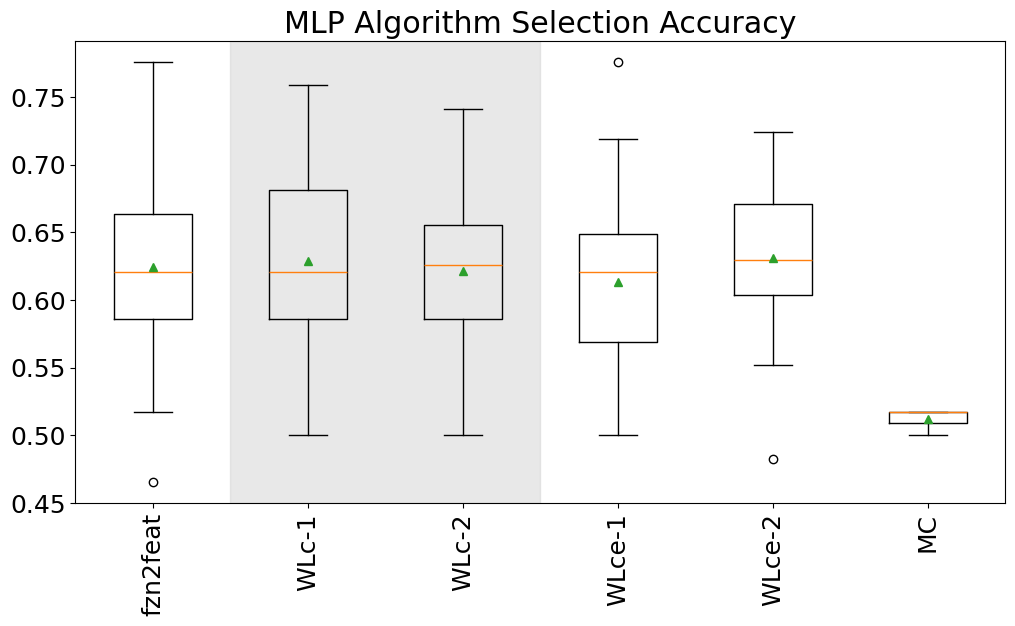

In [28]:
folder = '../data/as-accuracy-results/nn-scores'
matplotlib.rcParams['font.family'] = 'sans-serif'

matplotlib.rcParams.update({'font.size': 18})
print(folder, ':')
res_nn = get_as_accuracy_results(folder)
plot_res = {
    features: list(v.values()) for features, v in res_nn.items() if 'wlc' in features or 'fzn2feat' == features or 'majority_classifier' == features
}
fig, ax = plt.subplots(figsize=(12,6))
violin_parts = ax.boxplot(plot_res.values(), showmeans=True)

ax.set_xlim(.5, len(plot_res.keys())+.5)
ax.axvspan(1.5, 3.5, color='lightgrey', alpha=0.5)
ax.set_title("MLP Algorithm Selection Accuracy")

plt.xticks([i for i in range(1, len(plot_res.keys())+1)], [
    k.replace("wl", "WL") if k != 'majority_classifier' else 'MC' for k in plot_res.keys()], 
    rotation='vertical')
plt.savefig('../paper/figures/wl-fzn2feat_accuracy_nn.pdf', format='pdf', bbox_inches='tight',)
plt.show()

In [39]:
res_svc = get_as_accuracy_results('../data/as-accuracy-results/svc-scores')
res_forest = get_as_accuracy_results('../data/as-accuracy-results/forest-scores')
fzn2feat = list(res_forest['fzn2feat'].values())
wlc1 = list(res_svc['wlc-1'].values())
wlc2 = list(res_svc['wlc-2'].values())
t_stat, p_value = stats.wilcoxon(wlc1, fzn2feat)
print('wlc-1', p_value, compare_as_accuracy_results(('wlc-1', 'svc'),('fzn2feat', 'forest'), '../data/as-accuracy-results'))
t_stat, p_value = stats.wilcoxon(wlc2, fzn2feat)
print('wlc-2', p_value, compare_as_accuracy_results(('wlc-1', 'svc'),('fzn2feat', 'forest'), '../data/as-accuracy-results'))

wlc-1 0.036793817392207114 (0.6948096885813149, 0.6667820069204152, 0.0006394217955246711)
wlc-2 0.10811727228326116 (0.6948096885813149, 0.6667820069204152, 0.0006394217955246711)


# Parallel Predictions

In [9]:
folder = '../data/parallelise-results/svc-parallelise'
print(folder, ':')
res = get_parallel_results(folder)
fzn2feat = list(res['fzn2feat'].values())
t_stat, p_value = stats.wilcoxon(list(res['wlc-1'].values()), fzn2feat)
print("wlc-1", p_value, compare_par_results(('wlc-1', 'svc'),('fzn2feat', 'svc'), '../data/parallelise-results'))
t_stat, p_value = stats.wilcoxon(list(res['wlc-2'].values()), fzn2feat)
print("wlc-2", p_value, compare_par_results(('wlc-2', 'svc'),('fzn2feat', 'svc'), '../data/parallelise-results'))
t_stat, p_value = stats.wilcoxon(list(res['wlce-1'].values()), fzn2feat)
print("wlce-1", p_value, compare_par_results(('wlce-1', 'svc'),('fzn2feat', 'svc'), '../data/parallelise-results'))
t_stat, p_value = stats.wilcoxon(list(res['wlce-2'].values()), fzn2feat)
print("wlce-2", p_value, compare_par_results(('wlce-2', 'svc'),('fzn2feat', 'svc'), '../data/parallelise-results'))
display(to_table(res))

../data/parallelise-results/svc-parallelise :
wlc-1 0.9754406622954468 (0.6224080267558528, 0.6224080267558528, 0.9728291975570047)
wlc-2 0.2691755442004541 (0.6107023411371237, 0.6224080267558528, 0.24158985241398526)
wlce-1 0.6876822045635382 (0.6183946488294314, 0.6224080267558528, 0.7072635078841193)
wlce-2 0.844018041781945 (0.6250836120401337, 0.6224080267558528, 0.8057171222296344)


,Mean,Median,Std,Max,Min,Worse_sbs
fzn2feat,0.622345,0.633333,0.064783,0.733333,0.450000,0
wl-1,0.569237,0.559322,0.065106,0.683333,0.416667,0
wle-1,0.558141,0.566667,0.069771,0.683333,0.350000,0
wln-1,0.624802,0.616667,0.060718,0.750000,0.516667,0
wln-2,0.604028,0.600000,0.064954,0.728814,0.500000,0
wlne-1,0.633119,0.627119,0.056318,0.766667,0.516667,0
wlne-2,0.604367,0.600000,0.064464,0.733333,0.500000,0
wlc-1,0.622339,0.633333,0.062975,0.800000,0.500000,0
wlc-2,0.610712,0.605085,0.057701,0.750000,0.466667,0
wlce-1,0.618339,0.633333,0.062875,0.800000,0.500000,0


../data/parallelise-results/svc-parallelise :


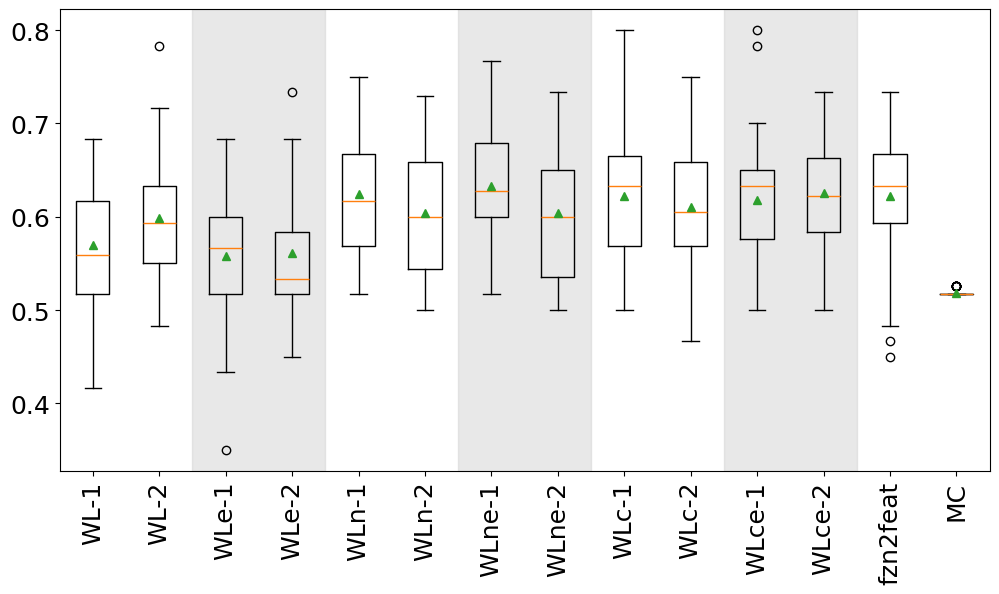

In [35]:
folder = '../data/parallelise-results/svc-parallelise'
matplotlib.rcParams['font.family'] = 'sans-serif'

matplotlib.rcParams.update({'font.size': 18})
print(folder, ':')
res_svc = get_parallel_results(folder)
plot_res = {
    features: list(v.values()) for features, v in res_svc.items()
}
fzn2feat = plot_res['fzn2feat']
del plot_res['fzn2feat']
plot_res['fzn2feat'] = fzn2feat

majority_classifier = plot_res['majority_classifier']
del plot_res['majority_classifier']
plot_res['majority_classifier'] = majority_classifier
fig, ax = plt.subplots(figsize=(12,6))
violin_parts = ax.boxplot(plot_res.values(), showmeans=True)

ax.set_xlim(0.5, len(plot_res.keys())+.5)
ax.axvspan(2.5, 4.5, color='lightgrey', alpha=0.5)
ax.axvspan(6.5, 8.5, color='lightgrey', alpha=0.5)
ax.axvspan(10.5, 12.5, color='lightgrey', alpha=0.5)

plt.xticks([i for i in range(1, len(plot_res.keys())+1)], [
    k.replace("wl", "WL") if k != 'majority_classifier' else 'MC' for k in plot_res.keys()], 
    rotation='vertical')
plt.savefig('../paper/figures/wl_par_svc.pdf', format='pdf', bbox_inches='tight',)
plt.show()

In [7]:
print('Statistical significance matrix (no fzn2feat):')
folder = '../data/parallelise-results/svc-parallelise'
WORSE = '\\textcolor{red}{$\\times$}'
BETTER = '\\textcolor{ForestGreen}{\\checkmark}'
EQUAL = '\\textbf{--}'

res_svc = get_parallel_results(folder)
features = [f for f in res_svc.keys() if f != 'fzn2feat' and f != 'majority_classifier']
features.append('fzn2feat')
features.append('majority_classifier')
rows = {feat:{ft:'' for ft in features} for feat in features}
for ft1 in features:
    for ft2 in features:
        if ft1 in ['wl-2', 'wle-2'] or ft2 in ['wl-2', 'wle-2']:
            continue
        if ft1 == ft2:
            rows[ft1][ft2] = EQUAL
            continue
        ft1_results = list(res_svc[ft1].values())
        ft2_results = list(res_svc[ft2].values())
        try:
            _, p_value = stats.wilcoxon(ft1_results, ft2_results)
            _, _, p_value = compare_par_results((ft1, 'svc'),(ft2, 'svc'), '../data/parallelise-results')
        except Exception as e:
            print(ft1, ft2)
            raise e
        if p_value < .05:
            if np.median(ft1_results) > np.median(ft2_results):
                rows[ft2][ft1] = BETTER
            else:
                rows[ft2][ft1] = WORSE
        else:
            rows[ft1][ft2] = EQUAL
print(pd.DataFrame(rows).to_latex())

Statistical significance matrix (no fzn2feat):
\begin{tabular}{lllllllllllllll}
\toprule
 & wl-1 & wl-2 & wle-1 & wle-2 & wln-1 & wln-2 & wlne-1 & wlne-2 & wlc-1 & wlc-2 & wlce-1 & wlce-2 & fzn2feat & majority_classifier \\
\midrule
wl-1 & \textbf{--} &  & \textbf{--} &  & \textcolor{red}{$\times$} & \textcolor{red}{$\times$} & \textcolor{red}{$\times$} & \textcolor{red}{$\times$} & \textcolor{red}{$\times$} & \textcolor{red}{$\times$} & \textcolor{red}{$\times$} & \textcolor{red}{$\times$} & \textcolor{red}{$\times$} & \textcolor{ForestGreen}{\checkmark} \\
wl-2 &  &  &  &  &  &  &  &  &  &  &  &  &  &  \\
wle-1 & \textbf{--} &  & \textbf{--} &  & \textcolor{red}{$\times$} & \textcolor{red}{$\times$} & \textcolor{red}{$\times$} & \textcolor{red}{$\times$} & \textcolor{red}{$\times$} & \textcolor{red}{$\times$} & \textcolor{red}{$\times$} & \textcolor{red}{$\times$} & \textcolor{red}{$\times$} & \textcolor{ForestGreen}{\checkmark} \\
wle-2 &  &  &  &  &  &  &  &  &  &  &  &  &  &  \\
w

In [20]:
folder = '../data/parallelise-results/nn-parallelise'
print(folder, ':')
res = get_parallel_results(folder)
fzn2feat = list(res['fzn2feat'].values())
t_stat, p_value = stats.wilcoxon(list(res['wlc-1'].values()), fzn2feat)
print("wlc-1", p_value, compare_par_results(('wlc-1', 'svc'),('fzn2feat', 'svc'), '../data/parallelise-results'))
t_stat, p_value = stats.wilcoxon(list(res['wlc-2'].values()), fzn2feat)
print("wlc-2", p_value, compare_par_results(('wlc-2', 'svc'),('fzn2feat', 'svc'), '../data/parallelise-results'))
# t_stat, p_value = stats.wilcoxon(list(res['wlce-1'].values()), fzn2feat)
# print("wlce-1", p_value, compare_par_results(('wlce-1', 'svc'),('fzn2feat', 'svc'), '../data/parallelise-results'))
# t_stat, p_value = stats.wilcoxon(list(res['wlce-2'].values()), fzn2feat)
# print("wlce-2", p_value, compare_par_results(('wlce-2', 'svc'),('fzn2feat', 'svc'), '../data/parallelise-results'))
display(to_table(res))

../data/parallelise-results/nn-parallelise :
wlc-1 0.2523818543811752 (0.6224080267558528, 0.6224080267558528, 0.9728291975570047)
wlc-2 0.3253089997313753 (0.6107023411371237, 0.6224080267558528, 0.24158985241398526)


,Mean,Median,Std,Max,Min,Worse_sbs
fzn2feat,0.660797,0.655508,0.060308,0.800000,0.525424,0
wlc-1,0.647458,0.633333,0.058995,0.783333,0.500000,0
wlc-2,0.652181,0.650000,0.054271,0.783333,0.500000,0
wlce-1,0.658727,0.650000,0.054681,0.816667,0.550000,0
majority_classifier,0.518418,0.516667,0.003538,0.525424,0.516667,0
wln-1,0.625000,0.625000,0.035355,0.650000,0.600000,0
wlne-1,0.666667,0.666667,0.000000,0.666667,0.666667,0


../data/parallelise-results/nn-parallelise :


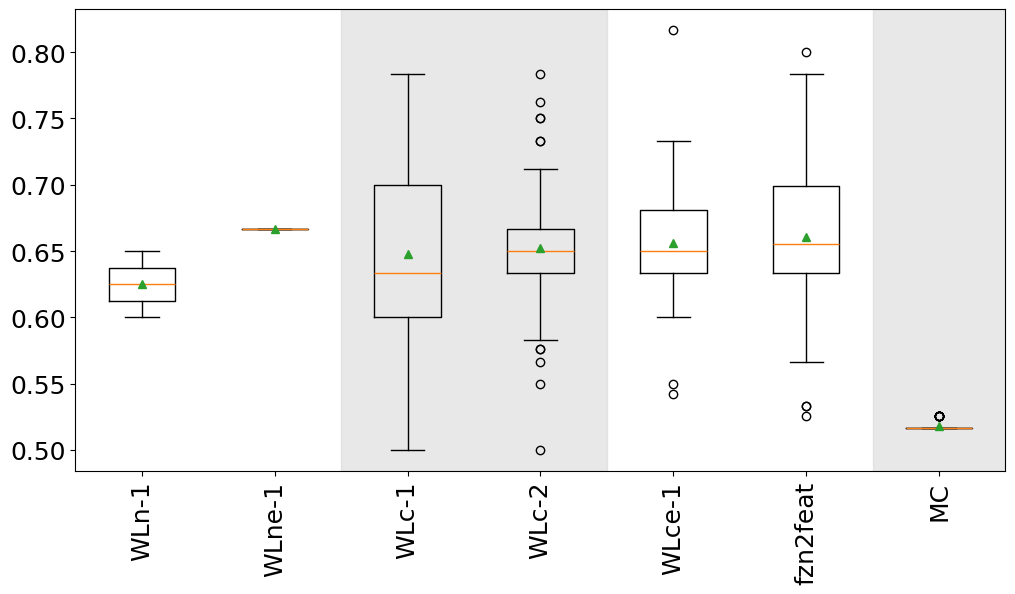

In [9]:
folder = '../data/parallelise-results/nn-parallelise'
matplotlib.rcParams['font.family'] = 'sans-serif'

matplotlib.rcParams.update({'font.size': 18})
print(folder, ':')
res_svc = get_parallel_results(folder)
plot_res = {
    features: list(v.values()) for features, v in res_svc.items()
}
fzn2feat = plot_res['fzn2feat']
del plot_res['fzn2feat']
plot_res['fzn2feat'] = fzn2feat

majority_classifier = plot_res['majority_classifier']
del plot_res['majority_classifier']
plot_res['majority_classifier'] = majority_classifier
fig, ax = plt.subplots(figsize=(12,6))
violin_parts = ax.boxplot(plot_res.values(), showmeans=True)

ax.set_xlim(0.5, len(plot_res.keys())+.5)
ax.axvspan(2.5, 4.5, color='lightgrey', alpha=0.5)
ax.axvspan(6.5, 8.5, color='lightgrey', alpha=0.5)
ax.axvspan(10.5, 12.5, color='lightgrey', alpha=0.5)

plt.xticks([i for i in range(1, len(plot_res.keys())+1)], [
    k.replace("wl", "WL") if k != 'majority_classifier' else 'MC' for k in plot_res.keys()], 
    rotation='vertical')
plt.savefig('../paper/figures/par_nn.pdf', format='pdf', bbox_inches='tight',)
plt.show()

In [11]:
for folder in ['../data/parallelise-results/forest-parallelise']:
    print(folder, ':')
    res = get_parallel_results(folder)
    fzn2feat = list(res['fzn2feat'].values())
    wlc1_forest = list(res['wlc-1'].values())
    t_stat, p_value = stats.wilcoxon(wlc1_forest, fzn2feat)
    print(p_value)
    display(to_table(res))

../data/parallelise-results/forest-parallelise :
5.2457127247969787e-05


,Mean,Median,Std,Max,Min,Worse_sbs
fzn2feat,0.575960,0.554661,0.074277,0.716667,0.383333,0
wl-1,0.595410,0.616667,0.054316,0.683333,0.483333,0
wle-1,0.642119,0.644068,0.051935,0.750000,0.516667,0
wln-1,0.634780,0.650000,0.056965,0.745763,0.416667,0
wln-2,0.645164,0.644068,0.051312,0.766667,0.533333,0
wlne-1,0.642763,0.647034,0.062914,0.800000,0.433333,0
wlne-2,0.642136,0.650000,0.054797,0.745763,0.483333,0
wlc-1,0.641774,0.633333,0.059415,0.766667,0.466667,0
wlc-2,0.634085,0.650000,0.063828,0.766667,0.483333,0
wlce-1,0.654169,0.650000,0.055703,0.783333,0.500000,0


../data/parallelise-results/forest-parallelise :


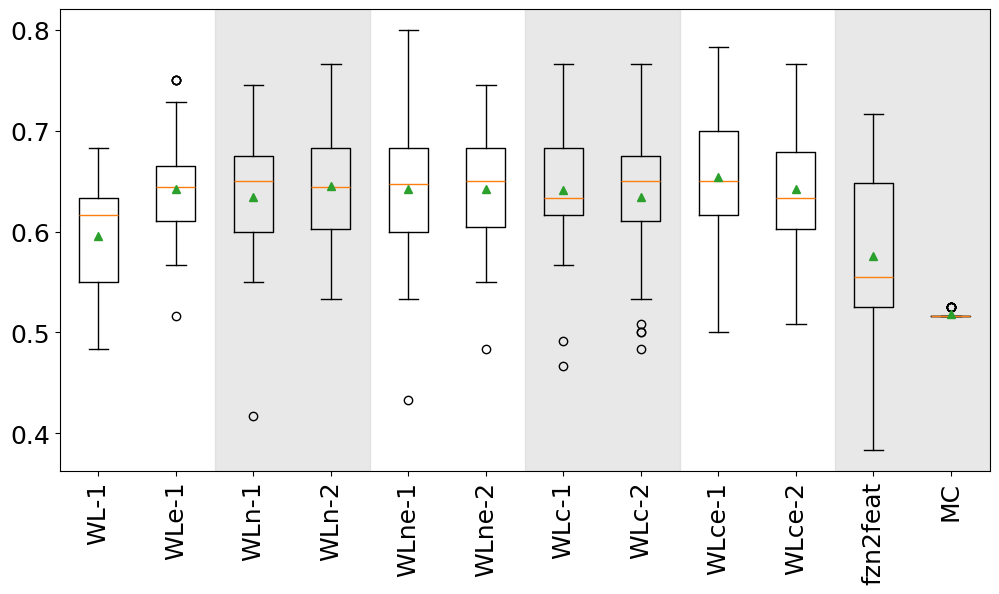

In [15]:
folder = '../data/parallelise-results/forest-parallelise'
matplotlib.rcParams['font.family'] = 'sans-serif'

matplotlib.rcParams.update({'font.size': 18})
print(folder, ':')
res_svc = get_parallel_results(folder)
plot_res = {
    features: list(v.values()) for features, v in res_svc.items()
}
fzn2feat = plot_res['fzn2feat']
del plot_res['fzn2feat']
plot_res['fzn2feat'] = fzn2feat

majority_classifier = plot_res['majority_classifier']
del plot_res['majority_classifier']
plot_res['majority_classifier'] = majority_classifier
fig, ax = plt.subplots(figsize=(12,6))
violin_parts = ax.boxplot(plot_res.values(), showmeans=True)

ax.set_xlim(0.5, len(plot_res.keys())+.5)
ax.axvspan(2.5, 4.5, color='lightgrey', alpha=0.5)
ax.axvspan(6.5, 8.5, color='lightgrey', alpha=0.5)
ax.axvspan(10.5, 12.5, color='lightgrey', alpha=0.5)

plt.xticks([i for i in range(1, len(plot_res.keys())+1)], [
    k.replace("wl", "WL") if k != 'majority_classifier' else 'MC' for k in plot_res.keys()], 
    rotation='vertical')
plt.savefig('../paper/figures/par_forest.pdf', format='pdf', bbox_inches='tight',)
plt.show()

# Feature Extraction Cost

In [3]:
wlc1 = pd.read_csv('../wlc1_extraction.csv')
wlc2 = pd.read_csv('../wlc2_extraction.csv')
fzn2feat = pd.read_csv('../fzn2feat_extraction.csv')

In [4]:
wlc1['wlc1_time'] = wlc1['time']
wlc1 = wlc1.drop(columns=['time'])
wlc2['wlc2_time'] = wlc2['time']
wlc2 = wlc2.drop(columns=['time'])
fzn2feat['fzn2feat_time'] = fzn2feat['time']
fzn2feat = fzn2feat.drop(columns=['time'])

In [5]:
merged = wlc1.merge(wlc2, on='name').merge(fzn2feat, on='name')
merged

,name,wlc1_time,wlc2_time,fzn2feat_time
0,portal-sep-small_3,0.102439,0.102300,0.022730
1,portal-sep-random_10_9_10,0.041639,0.039833,0.011155
2,portal-sep-random_20_9_100,0.654443,0.680940,0.183309
3,portal-sep-random_20_1_100,0.671200,0.689228,0.197974
4,portal-sep-random_10_0_100,0.559645,0.596811,0.096380
...,...,...,...,...
194,yumi-dynamic-sep-p_9_GSGS_GSGSG_yumi_grid_setu...,38.931360,38.877437,19.402926
195,yumi-dynamic-sep-p_5_GSS_SG_yumi_grid_setup_3_...,0.647183,0.649822,0.398652
196,yumi-dynamic-sep-p_5_GG_GGG_yumi_grid_setup_5_...,4.134264,4.095754,2.113800
197,yumi-dynamic-sep-p_4_GG_GG_yumi_grid_setup_5_5...,3.951888,3.948499,1.842363


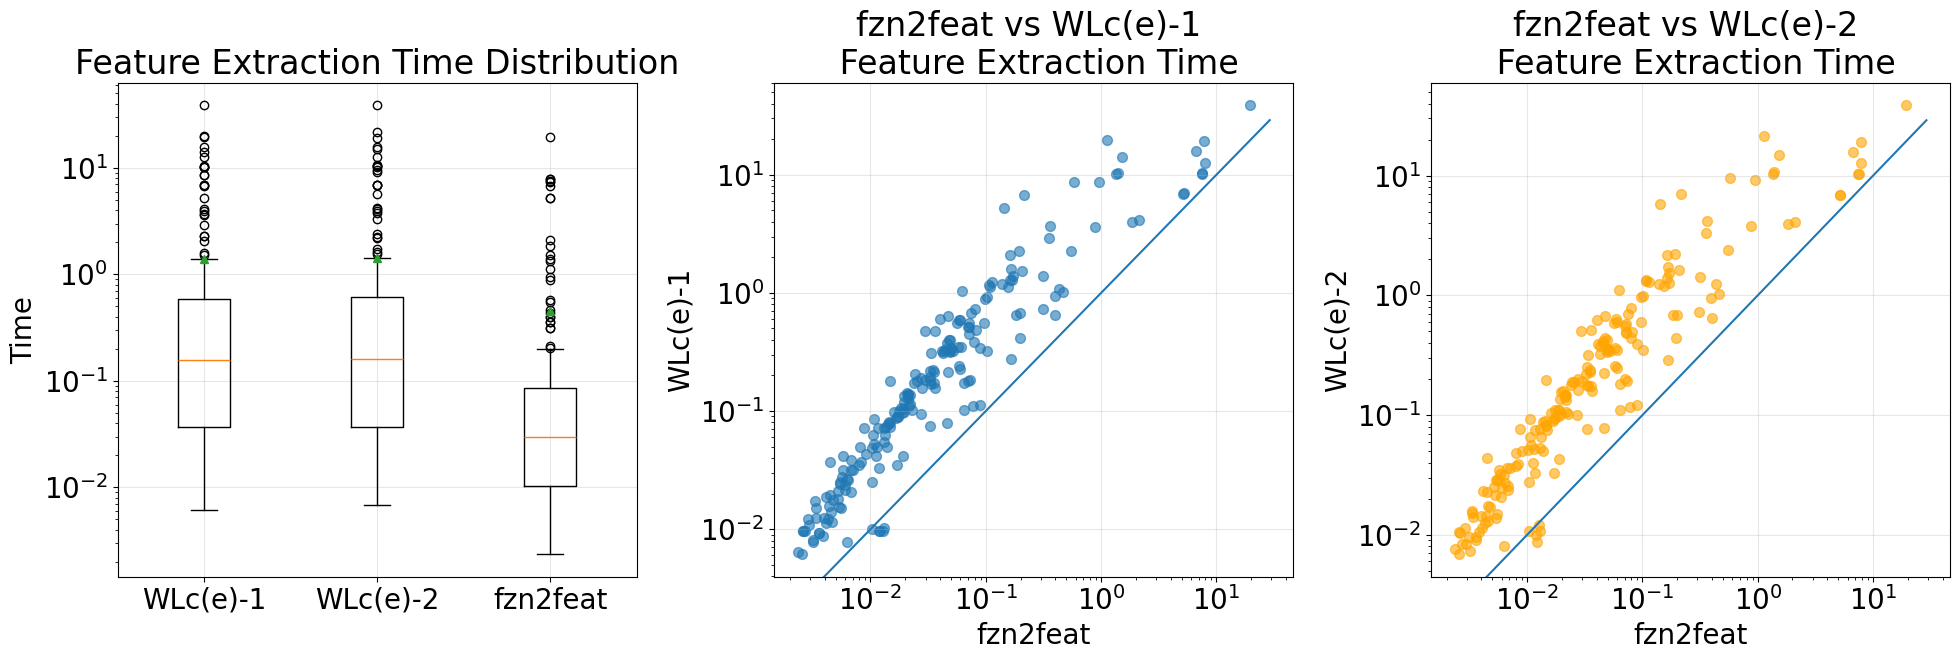

In [26]:
matplotlib.rcParams['font.family'] = 'sans-serif'

matplotlib.rcParams.update({'font.size': 20})
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
# 1. Boxplot - each time column as a separate box
time_columns = ['wlc1_time', 'wlc2_time', 'fzn2feat_time']
# merged[time_columns].boxplot(ax=axes[0])
axes[0].boxplot(merged[time_columns], showmeans=True)
axes[0].set_title('Feature Extraction Time Distribution')
axes[0].set_ylabel('Time')
axes[0].set_xticklabels(['WLc(e)-1', 'WLc(e)-2', 'fzn2feat'])
axes[0].grid(True, alpha=0.3)
axes[0].set_yscale('log')

# 2. First scatter plot: fzn2feat_time vs wlc1_time
axes[1].scatter(merged['fzn2feat_time'], merged['wlc1_time'], alpha=0.6, s=50)
axes[1].plot([i for i in range(30)], [i for i in range(30)])
axes[1].set_xlabel('fzn2feat')
axes[1].set_ylabel('WLc(e)-1')
axes[1].set_title('fzn2feat vs WLc(e)-1 \n Feature Extraction Time')
axes[1].grid(True, alpha=0.3)
axes[1].set_yscale('log')
axes[1].set_xscale('log')


# 3. Second scatter plot: fzn2feat_time vs wlc2_time
axes[2].scatter(merged['fzn2feat_time'], merged['wlc2_time'], alpha=0.6, s=50, color='orange')
axes[2].plot([i for i in range(30)], [i for i in range(30)])
axes[2].set_xlabel('fzn2feat')
axes[2].set_ylabel('WLc(e)-2')
axes[2].set_title('fzn2feat vs WLc(e)-2 \n Feature Extraction Time')
axes[2].grid(True, alpha=0.3)
axes[2].set_yscale('log')
axes[2].set_xscale('log')

# Adjust layout to prevent overlap
plt.tight_layout()

plt.savefig('../paper/figures/feature_extraction.pdf', format='pdf', bbox_inches='tight')
# Display the plot
plt.show()

In [31]:
import pickle
with open("../colors-2.pickle", 'rb') as f:
    dc = pickle.load(f)

In [32]:
len(set(dc.values()))

319